# 再犯风险评估模型 (Competitive Recidivism Risk Score)

目标：构建一个预测**两年内是否再犯**的模型，与 COMPAS 比较，并支持对单个被告的假释建议。  
**被告分配后**：在文末「单个被告预测」处填入 `defendant_id` 即可得到该被告的预测与建议。

## 1. 环境与数据加载

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RAW_PATH = "compas-scores-two-years.csv"

In [2]:
# 加载数据（处理重复列名：COMPAS 再犯分数用第二组 decile_score / score_text）
raw = pd.read_csv(RAW_PATH)
print("原始行数:", len(raw))
print("列名(含重复):", [c for c in raw.columns if 'decile' in c or c == 'score_text'])

原始行数: 7214
列名(含重复): ['decile_score', 'decile_score.1', 'score_text', 'v_decile_score']


## 2. 数据清洗（与 ProPublica 筛选逻辑一致）

- 筛查与逮捕间隔在 [-30, 30] 天
- `is_recid != -1`（有有效 COMPAS 案件）
- 排除交通违章 `c_charge_degree != 'O'`
- `score_text` 非 'N/A'

In [3]:
# 确定 COMPAS 再犯相关列（若存在重复列，第二组为再犯）
decile_cols = [c for c in raw.columns if c == 'decile_score' or (c.startswith('decile_score') and c != 'decile_score')]
compas_decile = 'decile_score.1' if 'decile_score.1' in raw.columns else 'decile_score'

df = raw.copy()
df['compas_decile'] = df[compas_decile]

df = df[
    (df['days_b_screening_arrest'] >= -30) &
    (df['days_b_screening_arrest'] <= 30) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != 'O') &
    (df['score_text'].notna()) &
    (df['score_text'].astype(str) != 'N/A')
].copy()

print("清洗后行数:", len(df))
print("两年再犯比例:", df['two_year_recid'].mean().round(3))

清洗后行数: 6172
两年再犯比例: 0.455


## 3. 特征与目标（建模时不使用 COMPAS 分数）

目标变量：`two_year_recid`。  
特征：仅用被告自身与案件信息，**不用** `decile_score` / `score_text`，以便与 COMPAS 公平比较。

In [4]:
target_col = 'two_year_recid'
id_col = 'id'

feature_cols_numeric = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'days_b_screening_arrest']
feature_cols_cat = ['sex', 'race', 'age_cat', 'c_charge_degree']
feature_cols = feature_cols_numeric + feature_cols_cat

# 保留用于后续比较和单被告展示的列
keep_cols = [id_col, 'name', 'compas_decile', 'score_text', 'is_violent_recid', 'c_charge_desc'] + feature_cols + [target_col]
df = df[[c for c in keep_cols if c in df.columns]].copy()

df = df.dropna(subset=feature_cols + [target_col])
print("用于建模的样本数:", len(df))
print("特征:", feature_cols)

用于建模的样本数: 6172
特征: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'days_b_screening_arrest', 'sex', 'race', 'age_cat', 'c_charge_degree']


## 4. 划分训练/测试集与预处理

In [5]:
X = df[feature_cols].copy()
y = df[target_col].astype(int)
ids = df[id_col]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), feature_cols_numeric),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), feature_cols_cat)
    ],
    remainder='passthrough'
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
feature_names_enc = (
    feature_cols_numeric
    + list(preprocessor.named_transformers_['cat'].get_feature_names_out(feature_cols_cat))
)
print("编码后特征数:", len(feature_names_enc))

编码后特征数: 15


## 5. 训练模型（逻辑回归 + 随机森林）

逻辑回归便于向法官解释系数；随机森林可作为对比或主模型。

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_enc, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_train_enc, y_train)

def evaluate(name, y_true, y_pred, y_proba=None):
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    if y_proba is not None:
        print("AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print(classification_report(y_true, y_pred, target_names=['No Recid', 'Recid']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

y_lr = lr.predict(X_test_enc)
y_lr_proba = lr.predict_proba(X_test_enc)[:, 1]
y_rf = rf.predict(X_test_enc)
y_rf_proba = rf.predict_proba(X_test_enc)[:, 1]

evaluate("Logistic Regression (Test)", y_test, y_lr, y_lr_proba)
evaluate("Random Forest (Test)", y_test, y_rf, y_rf_proba)

--- Logistic Regression (Test) ---
Accuracy: 0.6785
AUC: 0.7284
              precision    recall  f1-score   support

    No Recid       0.71      0.69      0.70       841
       Recid       0.64      0.67      0.65       702

    accuracy                           0.68      1543
   macro avg       0.68      0.68      0.68      1543
weighted avg       0.68      0.68      0.68      1543

Confusion Matrix:
[[580 261]
 [235 467]]
--- Random Forest (Test) ---
Accuracy: 0.6928
AUC: 0.7382
              precision    recall  f1-score   support

    No Recid       0.72      0.71      0.72       841
       Recid       0.66      0.68      0.67       702

    accuracy                           0.69      1543
   macro avg       0.69      0.69      0.69      1543
weighted avg       0.69      0.69      0.69      1543

Confusion Matrix:
[[595 246]
 [228 474]]


## 6. 与 COMPAS 比较（在测试集上）

将 COMPAS 的 decile 或 High/Medium/Low 视为“预测”，计算准确率与 AUC，与我们的模型对比。

In [8]:
test_df = df.loc[id_test.index].copy()
test_df = test_df.assign(
    pred_lr=y_lr, proba_lr=y_lr_proba,
    pred_rf=y_rf, proba_rf=y_rf_proba
)

# COMPAS：High 视为预测再犯(1)，Low/Medium 视为预测不再犯(0)；或按 decile 阈值
compas_high = (test_df['score_text'].astype(str).str.strip().str.lower() == 'high').astype(int)
compas_decile_val = pd.to_numeric(test_df['compas_decile'], errors='coerce').fillna(5)
compas_pred_decile = (compas_decile_val >= 5).astype(int)  # 5-10 视为高风险

print("COMPAS (score_text High=1):")
evaluate("COMPAS (High=Recid)", y_test.values, compas_high.values)
print("\nCOMPAS (decile>=5 为高风险):")
evaluate("COMPAS (decile>=5)", y_test.values, compas_pred_decile.values)

COMPAS (score_text High=1):
--- COMPAS (High=Recid) ---
Accuracy: 0.6364
              precision    recall  f1-score   support

    No Recid       0.61      0.92      0.73       841
       Recid       0.76      0.29      0.42       702

    accuracy                           0.64      1543
   macro avg       0.69      0.61      0.58      1543
weighted avg       0.68      0.64      0.59      1543

Confusion Matrix:
[[776  65]
 [496 206]]

COMPAS (decile>=5 为高风险):
--- COMPAS (decile>=5) ---
Accuracy: 0.6598
              precision    recall  f1-score   support

    No Recid       0.68      0.70      0.69       841
       Recid       0.63      0.61      0.62       702

    accuracy                           0.66      1543
   macro avg       0.66      0.66      0.66      1543
weighted avg       0.66      0.66      0.66      1543

Confusion Matrix:
[[588 253]
 [272 430]]


## 5.1 模型性能可视化

混淆矩阵热力图（逻辑回归）与 ROC 曲线（LR、RF、COMPAS decile 作为连续分数）。

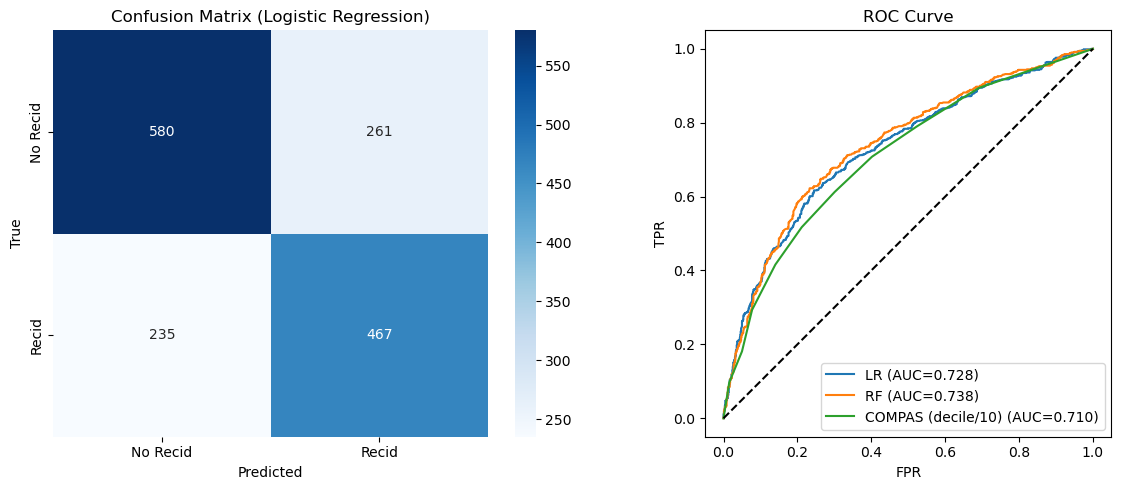

In [13]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 混淆矩阵热力图（逻辑回归）
cm_lr = confusion_matrix(y_test, y_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Recid', 'Recid'], yticklabels=['No Recid', 'Recid'])
axes[0].set_title('Confusion Matrix (Logistic Regression)')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# 混淆矩阵热力图（随机森林）
cm_rf = confusion_matrix(y_test, y_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Recid', 'Recid'], yticklabels=['No Recid', 'Recid'])
axes[1].set_title('Confusion Matrix (Random Forest)')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

# ROC 曲线
compas_score = pd.to_numeric(test_df['compas_decile'], errors='coerce').fillna(5) / 10
for name, y_proba in [('LR', y_lr_proba), ('RF', y_rf_proba), ('COMPAS (decile/10)', compas_score)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[2].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].set_aspect('equal')
plt.tight_layout()
plt.show()

## 6.1 与 COMPAS 指标对比图

同一测试集上 Accuracy、AUC、F1 的对比。

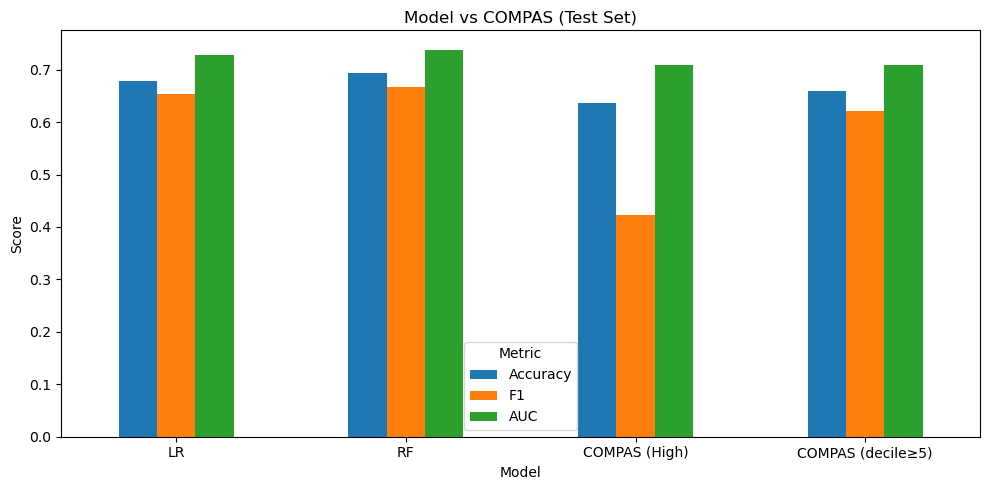

In [14]:
compas_high_arr = (test_df['score_text'].astype(str).str.strip().str.lower() == 'high').astype(int).values
compas_decile_arr = (pd.to_numeric(test_df['compas_decile'], errors='coerce').fillna(5) >= 5).astype(int).values
compas_score_auc = pd.to_numeric(test_df['compas_decile'], errors='coerce').fillna(5) / 10

rows = []
for name, y_p, y_proba in [
    ('LR', y_lr, y_lr_proba),
    ('RF', y_rf, y_rf_proba),
    ('COMPAS (High)', compas_high_arr, compas_score_auc),
    ('COMPAS (decile≥5)', compas_decile_arr, compas_score_auc),
]:
    acc = accuracy_score(y_test, y_p)
    f1 = f1_score(y_test, y_p, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    rows.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})
compare_df = pd.DataFrame(rows)

ax = compare_df.set_index('Model')[['Accuracy', 'F1', 'AUC']].plot(kind='bar', figsize=(10, 5), rot=0)
ax.set_ylabel('Score')
ax.set_title('Model vs COMPAS (Test Set)')
ax.legend(title='Metric')
plt.tight_layout()
plt.show()

## 7. 公平性分析（按种族）

参考 ProPublica：比较黑人/白人被告的假阳性率、假阴性率。

## 7.1 公平性可视化（按种族 FPR / FNR）

黑人 vs 白人被告的假阳性率、假阴性率对比（逻辑回归 vs COMPAS High=再犯）。

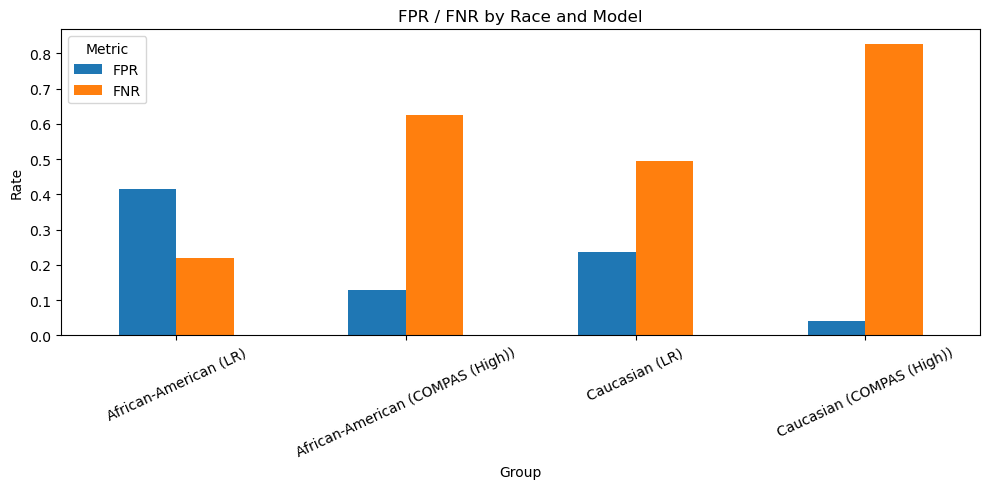

In [15]:
def fpr_fnr_row(y_true, y_pred, group_name, group_mask):
    if group_mask.sum() == 0:
        return None
    y_g, p_g = y_true[group_mask], y_pred[group_mask]
    tn, fp, fn, tp = confusion_matrix(y_g, p_g).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    return [group_name, fpr, fnr]

fair_rows = []
for race_label, mask in [('African-American', black), ('Caucasian', white)]:
    for model_name, pred in [('LR', y_lr), ('COMPAS (High)', compas_high.values)]:
        r = fpr_fnr_row(y_t, pred, f'{race_label} ({model_name})', mask)
        if r:
            fair_rows.append({'Group': r[0], 'FPR': r[1], 'FNR': r[2]})
fair_df = pd.DataFrame(fair_rows)

ax = fair_df.set_index('Group')[['FPR', 'FNR']].plot(kind='bar', figsize=(10, 5), rot=25)
ax.set_ylabel('Rate')
ax.set_title('FPR / FNR by Race and Model')
ax.legend(title='Metric')
plt.tight_layout()
plt.show()

In [9]:
def fairness_metrics(y_true, y_pred, group_name, group_mask):
    if group_mask.sum() == 0:
        return
    y_g, p_g = y_true[group_mask], y_pred[group_mask]
    tn, fp, fn, tp = confusion_matrix(y_g, p_g).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0   # 未再犯却被判高风险的比例
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0   # 再犯却被判低风险的比例
    print(f"{group_name}: 样本数={group_mask.sum()}, FPR(假阳性率)={fpr:.3f}, FNR(假阴性率)={fnr:.3f}")

black = (test_df['race'] == 'African-American').values
white = (test_df['race'] == 'Caucasian').values
y_t = y_test.values

print("=== 逻辑回归 ===")
fairness_metrics(y_t, y_lr, "African-American", black)
fairness_metrics(y_t, y_lr, "Caucasian", white)
print("\n=== COMPAS (High=Recid) ===")
fairness_metrics(y_t, compas_high.values, "African-American", black)
fairness_metrics(y_t, compas_high.values, "Caucasian", white)

=== 逻辑回归 ===
African-American: 样本数=803, FPR(假阳性率)=0.416, FNR(假阴性率)=0.221
Caucasian: 样本数=529, FPR(假阳性率)=0.237, FNR(假阴性率)=0.495

=== COMPAS (High=Recid) ===
African-American: 样本数=803, FPR(假阳性率)=0.130, FNR(假阴性率)=0.624
Caucasian: 样本数=529, FPR(假阳性率)=0.042, FNR(假阴性率)=0.827


## 8. 模型驱动因素（特征重要性）

便于向法官解释：哪些因素对预测影响最大。

## 8.1 驱动因素可视化

逻辑回归系数（绝对值）与随机森林特征重要性（前 10）。

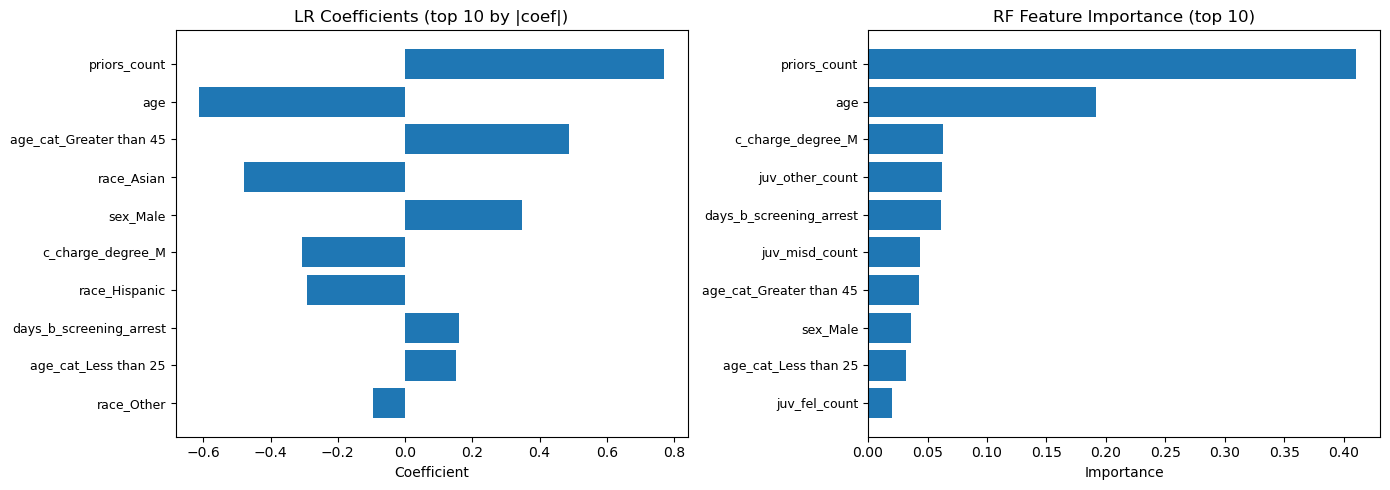

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_show = 10
coef_top = coef.head(n_show)
axes[0].barh(range(len(coef_top)), coef_top.values)
axes[0].set_yticks(range(len(coef_top)))
axes[0].set_yticklabels(coef_top.index, fontsize=9)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('LR Coefficients (top 10 by |coef|)')
axes[0].invert_yaxis()

imp_top = imp.head(n_show)
axes[1].barh(range(len(imp_top)), imp_top.values)
axes[1].set_yticks(range(len(imp_top)))
axes[1].set_yticklabels(imp_top.index, fontsize=9)
axes[1].set_xlabel('Importance')
axes[1].set_title('RF Feature Importance (top 10)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
coef = pd.Series(lr.coef_.ravel(), index=feature_names_enc)
coef = coef.reindex(coef.abs().sort_values(ascending=False).index)
print("逻辑回归系数 (绝对值排序):")
print(coef.head(15))

imp = pd.Series(rf.feature_importances_, index=feature_names_enc).sort_values(ascending=False)
print("\n随机森林特征重要性:")
print(imp.head(15))

逻辑回归系数 (绝对值排序):
priors_count               0.770784
age                       -0.613107
age_cat_Greater than 45    0.488199
race_Asian                -0.477552
sex_Male                   0.347823
c_charge_degree_M         -0.307389
race_Hispanic             -0.291732
days_b_screening_arrest    0.161104
age_cat_Less than 25       0.152857
race_Other                -0.095680
juv_other_count            0.074825
juv_fel_count              0.031299
race_Native American       0.021019
race_Caucasian             0.011468
juv_misd_count             0.001423
dtype: float64

随机森林特征重要性:
priors_count               0.410038
age                        0.192070
c_charge_degree_M          0.062890
juv_other_count            0.062575
days_b_screening_arrest    0.061553
juv_misd_count             0.043691
age_cat_Greater than 45    0.043211
sex_Male                   0.035887
age_cat_Less than 25       0.031471
juv_fel_count              0.020117
race_Caucasian             0.013365
race_Hispanic        

## 9. 单个被告预测与假释建议（分配被告后在此填入 id）

**使用方式**：将下方 `defendant_id` 改为你被分配的被告的 `id`，运行本单元即可得到该被告的模型预测、与 COMPAS 对比及建议。  
法官风险偏好：暴力被告倾向不放过再犯（可接受较多假阳性）；非暴力被告倾向减少误拒假释。

In [17]:
defendant_id = None  # 分配被告后改为具体 id，例如 123

if defendant_id is None:
    print("请将 defendant_id 改为你被分配的被告 id 后再运行。")
    print("示例：defendant_id = 123")
else:
    row = df[df[id_col] == defendant_id]
    if len(row) == 0:
        print(f"未找到 id={defendant_id} 的被告，请确认其在清洗后数据中。")
    else:
        row = row.iloc[0]
        X_one = df.loc[df[id_col] == defendant_id, feature_cols]
        X_one_enc = preprocessor.transform(X_one)
        proba_lr = lr.predict_proba(X_one_enc)[0, 1]
        pred_lr = lr.predict(X_one_enc)[0]
        proba_rf = rf.predict_proba(X_one_enc)[0, 1]
        compas_d = row.get('compas_decile', row.get('decile_score', None))
        compas_t = row.get('score_text', 'N/A')
        is_violent = row.get('is_violent_recid', 0)
        actual = row[target_col]
        print(f"被告 id: {defendant_id}, 姓名: {row.get('name', 'N/A')}")
        print(f"本模型 再犯概率(LR): {proba_lr:.2%}, 预测: {'再犯' if pred_lr == 1 else '不再犯'}")
        print(f"本模型 再犯概率(RF): {proba_rf:.2%}")
        print(f"COMPAS: decile={compas_d}, score_text={compas_t}")
        print(f"当前指控/暴力再犯标记: is_violent_recid={is_violent}")
        print("--- 建议 ---")
        if is_violent or (compas_t and str(compas_t).strip().lower() == 'high' and compas_d and int(compas_d) >= 7):
            print("法官对暴力被告更保守：若模型或 COMPAS 均显示较高风险，建议谨慎假释。")
        if proba_lr < 0.4 and pred_lr == 0:
            print("本模型给出较低再犯概率且预测不再犯，可考虑支持假释并说明依据（特征驱动）。")
        elif proba_lr >= 0.5:
            print("本模型给出较高再犯概率，建议结合 COMPAS 与案情再决定是否假释。")
        print("（最终建议请结合法官风险容忍度与你的完整分析在展示中给出。）")
        # 单被告一页图：概率 + COMPAS + 前几大驱动因素
        compas_val = pd.to_numeric(compas_d, errors='coerce')
        compas_val = compas_val if not pd.isna(compas_val) else 0
        x_flat = X_one_enc.toarray()[0] if hasattr(X_one_enc, 'toarray') else np.ravel(X_one_enc)
        contrib = pd.Series(lr.coef_.ravel() * x_flat, index=feature_names_enc)
        contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].bar(['LR 再犯概率', 'COMPAS(decile/10)'], [proba_lr, compas_val / 10], color=['steelblue', 'coral'])
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel('Score')
        axes[0].set_title(f'被告 {defendant_id} 风险分数')
        axes[1].barh(range(len(contrib)), contrib.values)
        axes[1].set_yticks(range(len(contrib)))
        axes[1].set_yticklabels(contrib.index, fontsize=9)
        axes[1].set_xlabel('LR 贡献 (系数×特征值)')
        axes[1].set_title('前 5 大驱动因素')
        axes[1].invert_yaxis()
        plt.tight_layout()
        plt.show()

请将 defendant_id 改为你被分配的被告 id 后再运行。
示例：defendant_id = 123
